# Descriptive Statistics and Visualizations for Watch Dataset
This notebook provides an analysis of the watch dataset (`ds.csv`) by generating descriptive statistics and visualizations.

## Load Dataset
Load the dataset using pandas and display the first few rows.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load the dataset
file_path = 'datasets/watchbase_data_raw_scrapy.csv'
df = pd.read_csv(file_path)
df.head()

,Url,Brand,Family,Reference,Name,Movement,Produced,Limited,Case_Material,Glass,Case_Back,Case_Shape,Case_Diameter,Lug_Width,Water_Resistance,Dial_Color,Dial_Finish,Dial_Indexes,Dial_Hands,Price
0,https://watchbase.com/panerai/pocket-watches/p...,Panerai,Pocket Watches,PAM00529,Pocket Watch 3 Days Oro Bianco,Panerai caliber P.3000/10,2014 - 2014,"Yes, 50 units",White Gold,Sapphire,Hunter,Cushion,50.00 mm,NaN,50.00 m,Black,NaN,Mixed,Stick,63500.0
1,https://watchbase.com/patek-philippe/cubitus/5...,Patek Philippe,Cubitus,5821/1AR-001,Cubitus Date 45 Stainless Steel - Rose Gold / ...,Patek Philippe caliber 26‑330 S C,2024,No,NaN,Sapphire,Open,Square,45.00 mm,NaN,30.00 m,Blue,Sunburst,Stick / Dot,Stick,62280.0
2,https://watchbase.com/patek-philippe/cubitus/5...,Patek Philippe,Cubitus,5822P-001,Cubitus Instantaneous Grand Date Platinum / Blue,Patek Philippe caliber 240 PS CI J LU,2024,No,Platinum,Sapphire,Open,Square,45.00 mm,NaN,30.00 m,Blue,Sunburst,Stick / Dot,Stick,89830.0
3,https://watchbase.com/patek-philippe/cubitus/5...,Patek Philippe,Cubitus,5821/1A-001,Cubitus Date 45 Stainless Steel / Green,Patek Philippe caliber 26‑330 S C,2024,No,Stainless Steel,Sapphire,Open,Square,45.00 mm,NaN,30.00 m,Green,Sunburst,Stick / Dot,Stick,41920.0
4,https://watchbase.com/patek-philippe/cubitus/7...,Patek Philippe,Cubitus,7128/1R-001,Cubitus Date 40 Rose Gold / Brown,Patek Philippe caliber 26‑330 S C/434,2024,No,Rose Gold,Sapphire,Open,Square,40.00 mm,NaN,30.00 m,Brown,Sunburst,Stick / Dot,Stick,NaN


## Inspect Dataset
Check for missing values, data types, and basic information about the dataset.

In [22]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Display data types and basic information
print("\nDataset Info:")
df.info()

Missing values per column:
Url                    0
Brand                  0
Family                 0
Reference              0
Name                   0
Movement              17
Produced            1293
Limited                0
Case_Material       1107
Glass                102
Case_Back             15
Case_Shape            25
Case_Diameter         28
Lug_Width           2048
Water_Resistance     222
Dial_Color            35
Dial_Finish         4222
Dial_Indexes          98
Dial_Hands           213
Price               1163
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Url               6298 non-null   object 
 1   Brand             6298 non-null   object 
 2   Family            6298 non-null   object 
 3   Reference         6298 non-null   object 
 4   Name              6298 non-null   object 
 5   Move

## Generate Descriptive Statistics
Generate summary statistics for numerical columns and value counts for categorical columns.

In [23]:
df['Case_Diameter'] = df['Case_Diameter'].str.replace('mm', '').astype(float)
df['Lug_Width'] = df['Lug_Width'].str.replace('mm', '').astype(float)
df['Water_Resistance'] = df['Water_Resistance'].str.replace('m', '').astype(float)

In [24]:
num_columns = df.select_dtypes(include=['float64']).columns
cat_columns = ['Brand', 'Family', 'Limited', 'Case_Material', 'Glass', 
               'Case_Back', 'Case_Shape', 'Dial_Color', 'Dial_Finish', 'Dial_Indexes', 'Dial_Hands']

In [25]:
print("Summary statistics for numerical columns:")
print(df[num_columns].describe())

Summary statistics for numerical columns:
       Case_Diameter    Lug_Width  Water_Resistance           Price
count    6270.000000  4250.000000       6076.000000     5135.000000
mean       39.319027    20.084929        136.390719    13388.654528
std        10.057552     3.434416        306.471702    30827.613963
min        15.000000     6.000000          0.010000      450.000000
25%        36.600000    20.000000         30.000000     3060.000000
50%        41.000000    20.000000        100.000000     5940.000000
75%        42.100000    22.000000        120.000000    11500.000000
max       500.000000    32.000000      11000.000000  1000000.000000


In [26]:
print("Summary statistics for categorical columns:")
for col in cat_columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

Summary statistics for categorical columns:

Value counts for Brand:
Brand
Breitling         1252
Longines          1109
Omega              845
Rolex              796
Tudor              503
TAG Heuer          429
IWC                412
Patek Philippe     383
Panerai            352
Cartier            217
Name: count, dtype: int64

Value counts for Family:
Family
Heritage                     69
Pocket Watches               54
Record                       50
La Grande Classique          50
Presence                     50
                             ..
Targa Florio                  2
Crash de Cartier              2
Professional                  1
Professional Sports Watch     1
Francillon                    1
Name: count, Length: 199, dtype: int64

Value counts for Limited:
Limited
No                 5573
Yes, 1 unit          66
Yes, 500 units       65
Yes, 100 units       64
Yes, 1000 units      42
                   ... 
Yes, 163 units        1
Yes, 63 units         1
Yes, 176 units    

## Visualize Price Distribution
Create a histogram or KDE plot to visualize the distribution of the 'Price' column.

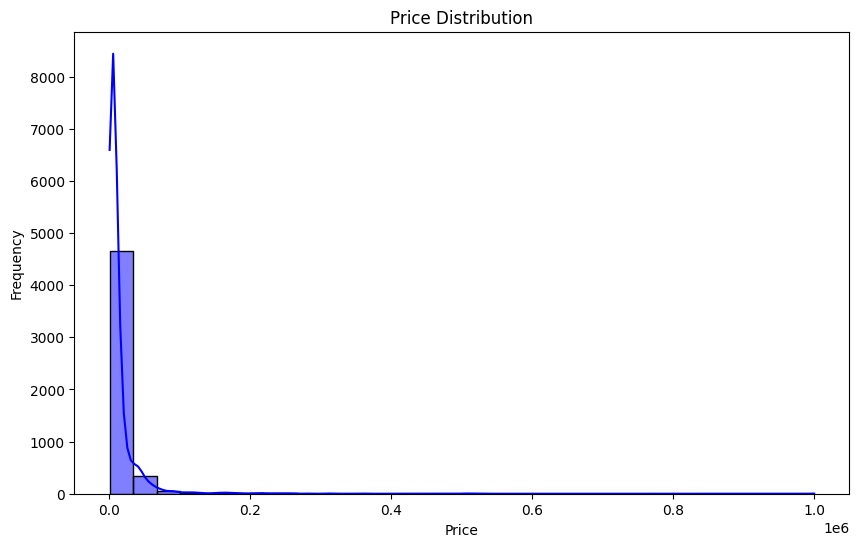

In [27]:
# Visualize the distribution of the 'Price' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=30, color='blue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

## Analyze Brand Distribution
Create a bar chart to show the count of watches for each brand.

C:\Users\DELL\AppData\Local\Temp\ipykernel_19504\493953537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Brand', data=df, order=df['Brand'].value_counts().index, palette='viridis')


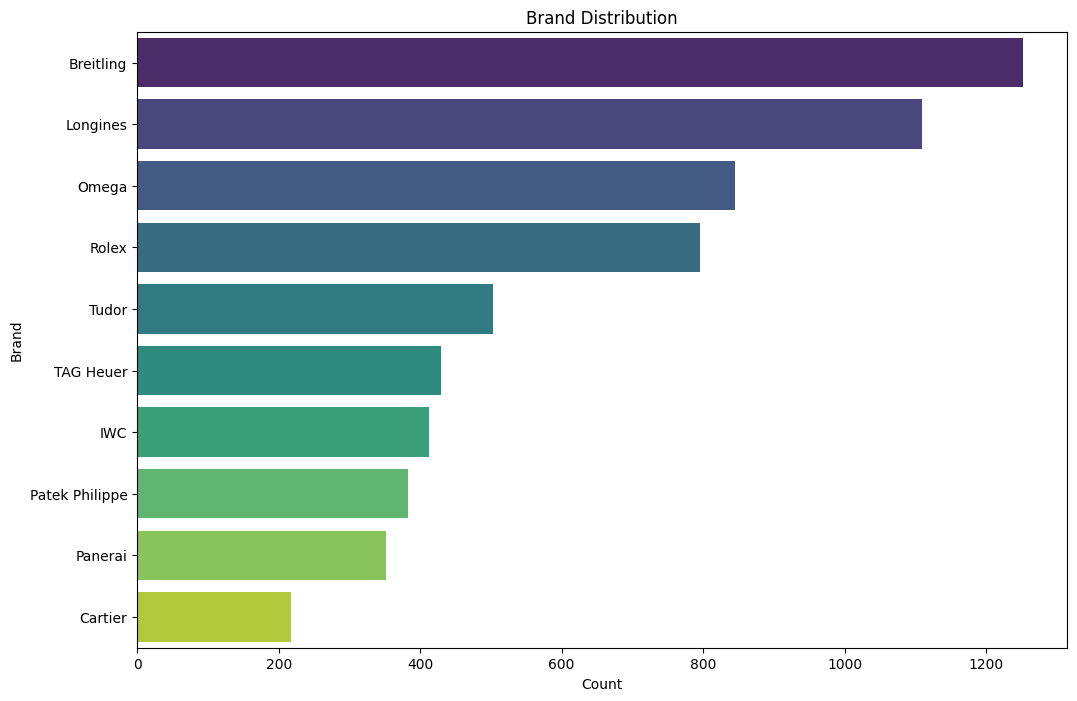

In [28]:
# Bar chart for brand distribution
plt.figure(figsize=(12, 8))
sns.countplot(y='Brand', data=df, order=df['Brand'].value_counts().index, palette='viridis')
plt.title('Brand Distribution')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.show()

## Analyze Case Material Distribution
Visualize the distribution of 'Case_Material' using a bar chart or pie chart.

C:\Users\DELL\AppData\Local\Temp\ipykernel_19504\1175056554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Case_Material', data=df, order=df['Case_Material'].value_counts().index, palette='coolwarm')


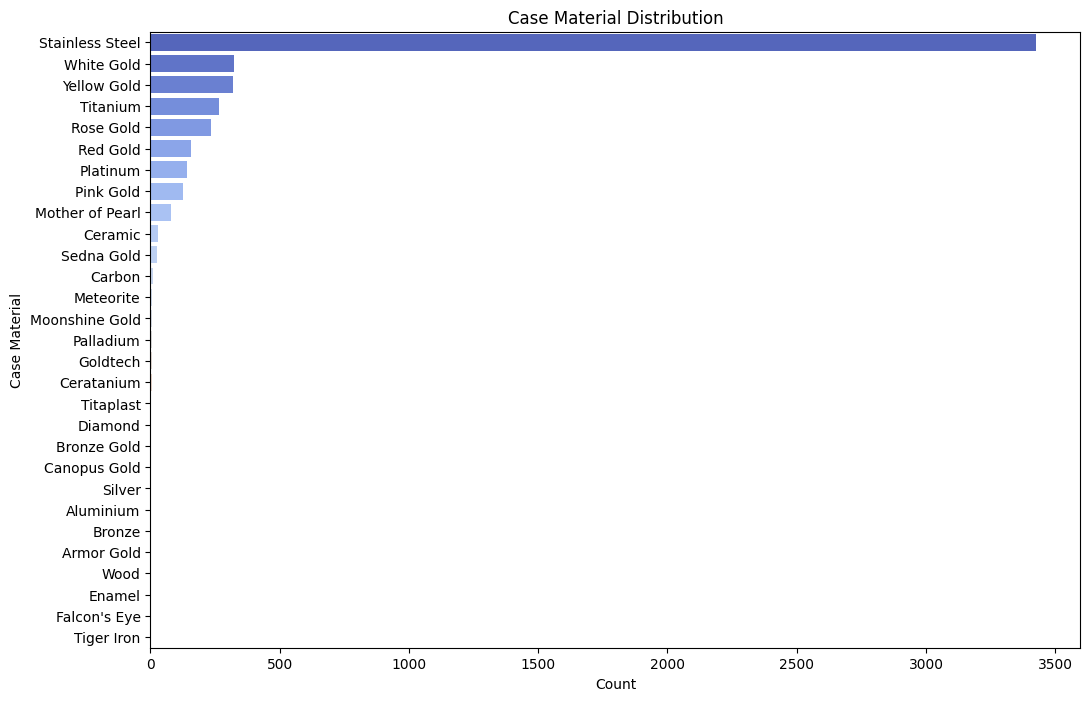

In [29]:
# Bar chart for case material distribution
plt.figure(figsize=(12, 8))
sns.countplot(y='Case_Material', data=df, order=df['Case_Material'].value_counts().index, palette='coolwarm')
plt.title('Case Material Distribution')
plt.xlabel('Count')
plt.ylabel('Case Material')
plt.show()

## Analyze Dial Color Distribution
Create a bar chart to show the distribution of 'Dial_Color' values.

C:\Users\DELL\AppData\Local\Temp\ipykernel_19504\754973263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Dial_Color', data=df, order=df['Dial_Color'].value_counts().index, palette='cubehelix')


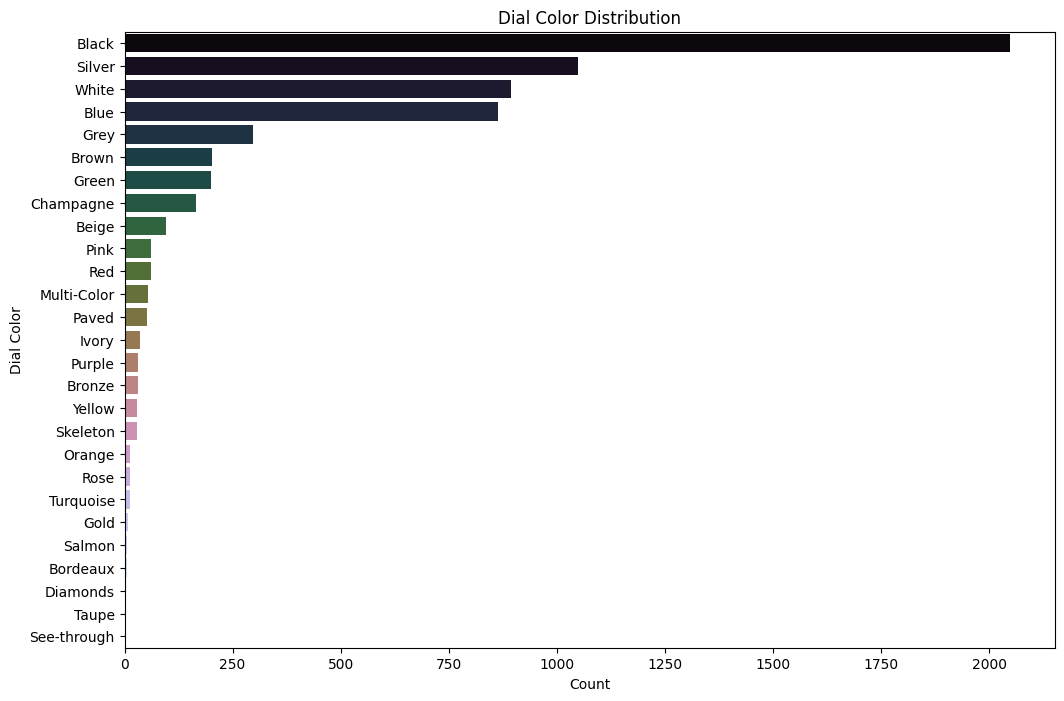

In [30]:
# Bar chart for dial color distribution
plt.figure(figsize=(12, 8))
sns.countplot(y='Dial_Color', data=df, order=df['Dial_Color'].value_counts().index, palette='cubehelix')
plt.title('Dial Color Distribution')
plt.xlabel('Count')
plt.ylabel('Dial Color')
plt.show()

## Analyze Price vs. Case Diameter
Create a scatter plot to analyze the relationship between 'Price' and 'Case_Diameter'.

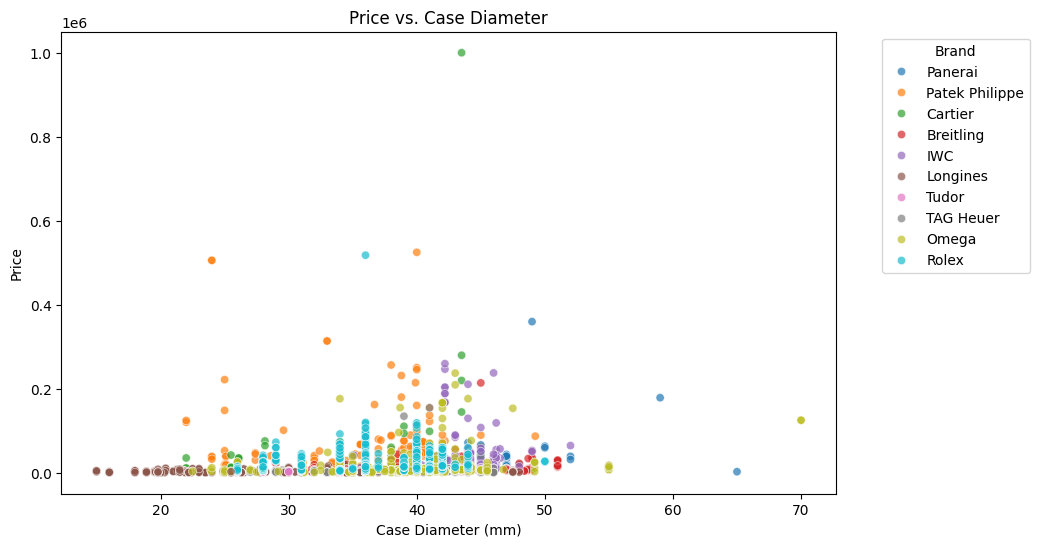

In [31]:
# Scatter plot for Price vs. Case Diameter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Case_Diameter', y='Price', data=df, hue='Brand', palette='tab10', alpha=0.7)
plt.title('Price vs. Case Diameter')
plt.xlabel('Case Diameter (mm)')
plt.ylabel('Price')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()